# Baseline Diagnostics Analysis

This notebook loads outputs from `experiment/run_baseline.py` and visualizes:

- KS-based empirical rejection curves for the four latent-space methods
- BCE label-model predicted stability probabilities on baseline vs shifted contexts
- Training histories for the saved baselines


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd()
if not (root / "results").exists() and (root.parent / "results").exists():
    root = root.parent
base = root / "results" / "diagnostics_results_baselines"



method_specs = {
    "pval": ("Proposed", "red"),
    "pval_base": ("Regularization only", "grey"),
    "pval_recon": ("Reconstruction only", "#1f77b4"),
    "pval_uniform": ("Uniform weight", "#2ca02c"),
    "pval_label": ("BCE label (binom)", "#ff7f0e"),
}

def fmt(x):
    return f"{x:g}".replace(".", "p")

def resolve_run_dir(seed, lr, lambda_mmd, loss_type, tau, perturb_type=None, epochs=None, n_samples=None):
    prefix = (
        f"seed_{seed}_lr_{fmt(lr)}_lambda_mmd_{fmt(lambda_mmd)}"
        f"_loss_type_{loss_type}_tau_{fmt(tau)}"
    )
    candidates = sorted(base.glob(f"{prefix}*"))
    if perturb_type is not None:
        candidates = [p for p in candidates if f"_perturb_type_{perturb_type}" in p.name]
    if epochs is not None:
        candidates = [p for p in candidates if f"_epochs_{epochs}" in p.name]
    if n_samples is not None:
        candidates = [p for p in candidates if f"_n_{n_samples}" in p.name]

    if not candidates:
        raise FileNotFoundError("No matching baseline run directory found.")
    if len(candidates) > 1:
        print("Multiple matches found; using the last one:")
        for cand in candidates:
            print("  ", cand)
    return candidates[-1]

def load_triplet(run_dir):
    df1 = pd.read_pickle(run_dir / "df1.pkl")
    df2 = pd.read_pickle(run_dir / "df2.pkl")
    df3 = pd.read_pickle(run_dir / "df3.pkl")
    return df1, df2, df3

def rejection_curve_with_band(series, alpha=0.1, z=1.6448536269514722):
    means, lo, hi = [], [], []
    for arr in series:
        rej = (np.asarray(arr, dtype=float) <= alpha).astype(float)
        n = len(rej)
        p = float(rej.mean())
        se = np.sqrt(max(p * (1.0 - p) / max(n, 1), 0.0))
        means.append(p)
        lo.append(max(0.0, p - z * se))
        hi.append(min(1.0, p + z * se))
    return np.asarray(means), np.asarray(lo), np.asarray(hi)

def setting_titles(perturb_type):
    if perturb_type == "mean":
        return [
            r"Setting 1 ($H_0$)",
            r"Setting 2 ($H_0 \to H_1$)",
            r"Setting 3 ($H_1$)",
        ]
    return ["Setting 1", "Setting 2", "Setting 3"]




Working directory: /Users/zhengminxing/Desktop/Research/Physics-Informed-Hypo-Test/experiment
Resolved base: /Users/zhengminxing/Desktop/Research/Physics-Informed-Hypo-Test/experiment/results/diagnostics_results_baselines
Loaded: /Users/zhengminxing/Desktop/Research/Physics-Informed-Hypo-Test/experiment/results/diagnostics_results_baselines/seed_11_lr_0p003_lambda_mmd_0p01_loss_type_stability_asymmetric_recon_tau_1_perturb_type_mean_epochs_150_n_8000
Files:
 - df1.pkl
 - df2.pkl
 - df3.pkl
 - gap_df.csv
 - gap_table.csv
 - label_probability_summary.csv
 - mean_summary.csv
 - mean_summary.json
 - rejection_rate_summary.csv
 - run_config.json
 - summary_df.csv
 - train_reconstruction_snapshot_proposed.pkl
 - train_reconstruction_snapshot_reconstruction_only.pkl
 - train_reconstruction_snapshot_uniform_weight.pkl
 - training_history_label_bce.csv
 - training_history_proposed.csv
 - training_history_reconstruction_only.csv
 - training_history_regularization_only.csv
 - training_history_uni

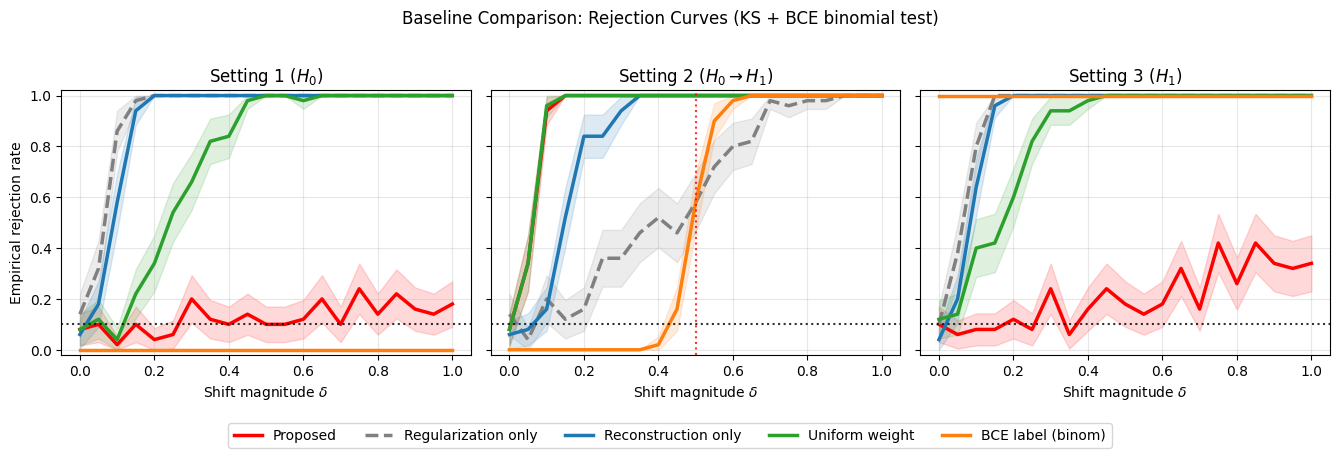

In [9]:
seed = 11
lr = 3e-3
lambda_mmd = 1e-2

tau = 1
loss_type = "stability_asymmetric_recon"
perturb_type = "mean"   # "mean" or "cov"
epochs = 150
n_samples = 8000
alpha = 0.1

# Optional delta range for each setting/panel.
# Use None to keep the full range for that panel.
delta_ranges = [
    (0.0, 1),   # Setting 1 / df1
    (0.0, 1),   # Setting 2 / df2
    (0.0, 1.0),   # Setting 3 / df3
]

run_dir = resolve_run_dir(
    seed=seed,
    lr=lr,
    lambda_mmd=lambda_mmd,
    loss_type=loss_type,
    tau=tau,
    perturb_type=perturb_type,
    epochs=epochs,
    n_samples=n_samples,
)

df1, df2, df3 = load_triplet(run_dir)
titles = setting_titles(perturb_type)

shared_cols = set(df1.columns) & set(df2.columns) & set(df3.columns)
available_method_specs = {
    col: spec for col, spec in method_specs.items() if col in shared_cols
}
missing_methods = [col for col in method_specs if col not in shared_cols]

print("Working directory:", Path.cwd())
print("Resolved base:", base)
print("Loaded:", run_dir)
print("Files:")
for path in sorted(run_dir.iterdir()):
    print(" -", path.name)
print("Available plotted methods:", list(available_method_specs))
if missing_methods:
    print("Missing method columns in these saved results:", missing_methods)

label_null = 1 - alpha
label_n = n_samples

def bce_binom_pvalue_from_mean_prob(mean_prob, n=5000, p0=0.9):
    mean_prob = float(np.clip(mean_prob, 0.0, 1.0))
    k_eff = int(np.rint(mean_prob * n))
    return float(stats.binomtest(k_eff, n=n, p=p0, alternative="less").pvalue)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True)

for ax, df, title, delta_range in zip(axes, [df1, df2, df3], titles, delta_ranges):
    df_plot = df.copy()

    if delta_range is not None:
        dmin, dmax = delta_range
        df_plot = df_plot[(df_plot["delta"] >= dmin) & (df_plot["delta"] <= dmax)].copy()

    delta = df_plot["delta"].to_numpy()

    for col, (label, color) in available_method_specs.items():
        mean, lo, hi = rejection_curve_with_band(df_plot[col], alpha=alpha)
        ax.fill_between(delta, lo, hi, color=color, alpha=0.15)
        ls = "--" if col == "pval_base" else "-"
        ax.plot(delta, mean, lw=2.5, color=color, ls=ls, label=label)

    # BCE binomial-test curve from stored mean predicted stability probability
    # if "label_prob_shift_mean" in df_plot.columns:
    #     pval_label = np.array([
    #         bce_binom_pvalue_from_mean_prob(m, n=label_n, p0=label_null)
    #         for m in df_plot["label_prob_shift_mean"].to_numpy()
    #     ])
    #     rej_label = (pval_label <= alpha).astype(float)
    #     ax.plot(delta, rej_label, lw=2.5, color="#ff7f0e", label="BCE label (binom)")

    ax.axhline(alpha, color="black", ls=":", lw=1.5, alpha=0.8)
    if perturb_type == "mean" and title.startswith("Setting 2"):
        ax.axvline(0.5, color="red", ls=":", lw=1.5, alpha=0.8)

    ax.set_title(title)
    ax.set_xlabel(r"Shift magnitude $\delta$")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Empirical rejection rate")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(labels), bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Baseline Comparison: Rejection Curves (KS + BCE binomial test)", y=1.02)
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


In [ ]:
# X train and unseen X test during training 
# boundary 
# Theta + perturbation 
# observation + perturbation 
# 

In [93]:

def fmt(x):
    return f"{x:g}".replace(".", "p")

def resolve_run_dir(seed, lr, lambda_mmd, loss_type, tau, perturb_type=None, epochs=None, n_samples=None):
    prefix = (
        f"seed_{seed}_lr_{fmt(lr)}_lambda_mmd_{fmt(lambda_mmd)}"
        f"_loss_type_{loss_type}_tau_{fmt(tau)}"
    )
    candidates = sorted(base.glob(f"{prefix}*"))
    if perturb_type is not None:
        candidates = [p for p in candidates if f"_perturb_type_{perturb_type}" in p.name]
    if epochs is not None:
        candidates = [p for p in candidates if f"_epochs_{epochs}" in p.name]
    if n_samples is not None:
        candidates = [p for p in candidates if f"_n_{n_samples}" in p.name]
    if not candidates:
        raise FileNotFoundError(f"No run found for seed={seed}")
    return candidates[-1]

def load_triplet(run_dir):
    df1 = pd.read_pickle(run_dir / "df1.pkl")
    df2 = pd.read_pickle(run_dir / "df2.pkl")
    df3 = pd.read_pickle(run_dir / "df3.pkl")
    return df1, df2, df3

def rejection_rate_from_array_col(series, alpha=0.1):
    return series.apply(lambda p: np.mean(np.asarray(p) <= alpha)).to_numpy()


In [108]:
lr = 1e-2
lambda_mmd = 1e-2
tau = 1
loss_type = "stability_asymmetric_recon"
perturb_type = "mean"
epochs = 100
n_samples = 5000
alpha = 0.1
seeds = range(101, 121)   # example: seeds for one (lambda, lr) block
boundary_delta = 0.5

method_cols = {
    "proposed": "pval",
    "reg_only": "pval_base",
    "recon_only": "pval_recon",
    "uniform_weight": "pval_uniform",
}
rows = []

for seed in seeds:
    run_dir = resolve_run_dir(
        seed=seed,
        lr=lr,
        lambda_mmd=lambda_mmd,
        loss_type=loss_type,
        tau=tau,
        perturb_type=perturb_type,
        epochs=epochs,
        n_samples=n_samples,
    )
    df1, df2, df3 = load_triplet(run_dir)

    for method_name, col in method_cols.items():
        if col not in df1.columns:
            continue

        rej1 = rejection_rate_from_array_col(df1[col], alpha=alpha)
        rej2 = rejection_rate_from_array_col(df2[col], alpha=alpha)
        rej3 = rejection_rate_from_array_col(df3[col], alpha=alpha)

        delta2 = df2["delta"].to_numpy()

        rows.append({
            "seed": seed,
            "method": method_name,
            "setting1_mean": float(np.mean(rej1)),
            "setting2_before": float(np.mean(rej2[delta2 < boundary_delta])),
            "setting2_after": float(np.mean(rej2[delta2 >= boundary_delta])),
            "setting3_mean": float(np.mean(rej3)),
        })

summary_per_seed = pd.DataFrame(rows)
summary_per_seed.head(4)


,seed,method,setting1_mean,setting2_before,setting2_after,setting3_mean
0,101,proposed,0.856190,0.504,0.998182,0.931429
1,101,reg_only,0.921905,0.834,1.000000,0.940000
2,101,recon_only,0.846667,0.680,1.000000,0.778095
3,101,uniform_weight,0.907619,0.614,1.000000,0.920952


In [109]:
proposed_seed_summary = (
    summary_per_seed[summary_per_seed["method"] == "proposed"]
    .copy()
    .sort_values(["setting1_mean", "setting3_mean"], ascending=[True, False])
    .reset_index(drop=True)
)

proposed_seed_summary.head(10)


,seed,method,setting1_mean,setting2_before,setting2_after,setting3_mean
0,109,proposed,0.633333,0.686,1.000000,0.656190
1,110,proposed,0.635238,0.886,1.000000,0.701905
2,119,proposed,0.676190,0.848,1.000000,0.672381
3,101,proposed,0.856190,0.504,0.998182,0.931429
4,112,proposed,0.865714,0.710,0.996364,0.869524
5,117,proposed,0.885714,0.396,1.000000,0.811429
6,120,proposed,0.900952,0.858,1.000000,0.924762
7,114,proposed,0.900952,0.820,1.000000,0.860952
8,115,proposed,0.903810,0.160,0.909091,0.888571
9,104,proposed,0.906667,0.610,0.845455,0.868571


In [90]:
summary_over_seeds = (
    summary_per_seed
    .groupby("method")
    .agg(
        setting1_mean_mean=("setting1_mean", "mean"),
        setting1_mean_std=("setting1_mean", "std"),
        setting2_before_mean=("setting2_before", "mean"),
        setting2_before_std=("setting2_before", "std"),
        setting2_after_mean=("setting2_after", "mean"),
        setting2_after_std=("setting2_after", "std"),
        setting3_mean_mean=("setting3_mean", "mean"),
        setting3_mean_std=("setting3_mean", "std"),
    )
    .reset_index()
)

summary_over_seeds


,method,setting1_mean_mean,setting1_mean_std,setting2_before_mean,setting2_before_std,setting2_after_mean,setting2_after_std,setting3_mean_mean,setting3_mean_std
0,proposed,0.869476,0.102010,0.7591,0.158690,0.987182,0.055637,0.824000,0.183335
1,recon_only,0.740524,0.117772,0.5450,0.217457,0.974455,0.097015,0.780190,0.100640
2,reg_only,0.864429,0.104129,0.7538,0.138786,0.999818,0.000560,0.896095,0.055921
3,uniform_weight,0.895333,0.052358,0.7529,0.190640,0.997182,0.010327,0.864048,0.088260


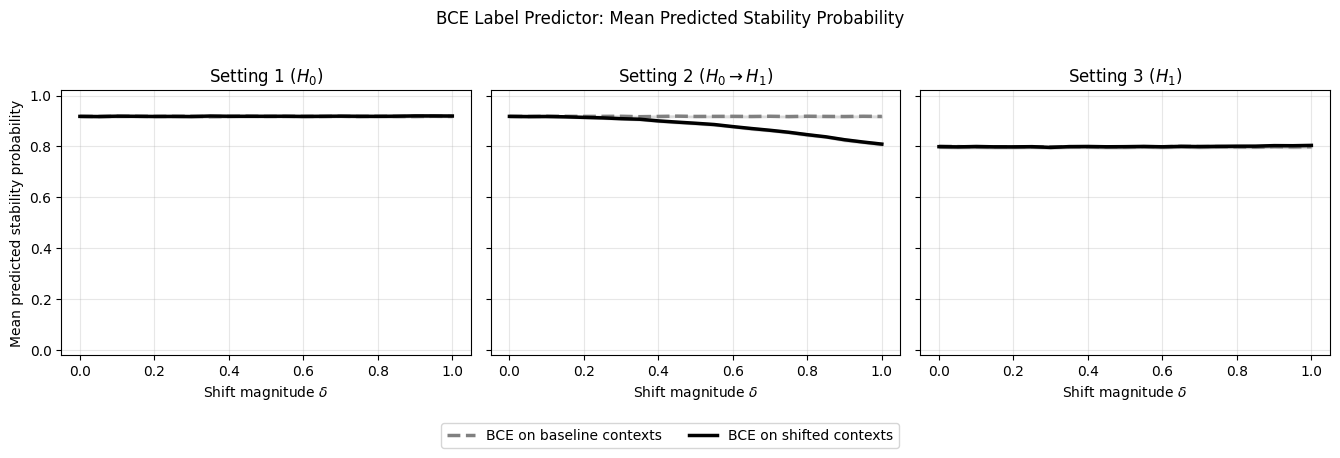

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True)

for ax, df, title in zip(axes, [df1, df2, df3], titles):
    delta = df["delta"].to_numpy()

    base_mean = df["label_prob_base_mean"].to_numpy(dtype=float)
    base_std = df["label_prob_base_std"].to_numpy(dtype=float)
    shift_mean = df["label_prob_shift_mean"].to_numpy(dtype=float)
    shift_std = df["label_prob_shift_std"].to_numpy(dtype=float)

    ax.fill_between(delta, np.clip(base_mean - base_std, 0, 1), np.clip(base_mean + base_std, 0, 1), alpha=0.18, color="grey")
    ax.fill_between(delta, np.clip(shift_mean - shift_std, 0, 1), np.clip(shift_mean + shift_std, 0, 1), alpha=0.18, color="black")
    ax.plot(delta, base_mean, color="grey", lw=2.5, ls="--", label="BCE on baseline contexts")
    ax.plot(delta, shift_mean, color="black", lw=2.5, label="BCE on shifted contexts")
    ax.set_title(title)
    ax.set_xlabel(r"Shift magnitude $\delta$")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Mean predicted stability probability")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("BCE Label Predictor: Mean Predicted Stability Probability", y=1.02)
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


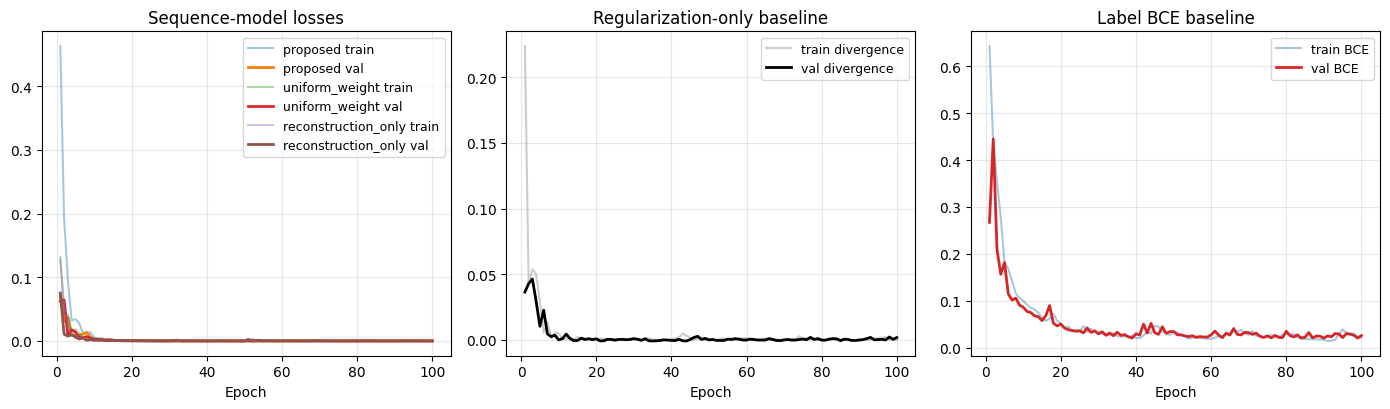

,metric,value
0,df1_gap_mean,-0.036190
1,df2_before_0.5_mean,0.140000
2,df2_after_0.5_mean,0.000000
3,df3_gap_mean,0.008571


,setting,delta,method,empirical_rejection_rate
0,df1,0.00,proposed,0.08
1,df1,0.05,proposed,0.66
2,df1,0.10,proposed,1.00
3,df1,0.15,proposed,1.00
4,df1,0.20,proposed,1.00


,delta,label_prob_base_mean,label_prob_base_std,label_prob_shift_mean,label_prob_shift_std,setting
0,0.00,0.916309,0.003579,0.916990,0.002833,df1
1,0.05,0.916482,0.003736,0.916240,0.004119,df1
2,0.10,0.916505,0.003905,0.916849,0.003723,df1
3,0.15,0.916833,0.003482,0.917368,0.004004,df1
4,0.20,0.917221,0.003865,0.915901,0.004117,df1


In [83]:
histories = {}
for path in sorted(run_dir.glob("training_history_*.csv")):
    name = path.stem.replace("training_history_", "")
    histories[name] = pd.read_csv(path)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

for name in ["proposed", "uniform_weight", "reconstruction_only"]:
    hist = histories[name]
    axes[0].plot(hist["epoch"], hist["train_loss"], alpha=0.4, label=f"{name} train")
    if "val_loss" in hist.columns:
        axes[0].plot(hist["epoch"], hist["val_loss"], lw=2, label=f"{name} val")
axes[0].set_title("Sequence-model losses")
axes[0].set_xlabel("Epoch")
axes[0].grid(True, alpha=0.3)

hist = histories["regularization_only"]
axes[1].plot(hist["epoch"], hist["train_divergence"], alpha=0.4, label="train divergence", color="grey")
if "val_divergence" in hist.columns:
    axes[1].plot(hist["epoch"], hist["val_divergence"], lw=2, label="val divergence", color="black")
axes[1].set_title("Regularization-only baseline")
axes[1].set_xlabel("Epoch")
axes[1].grid(True, alpha=0.3)

hist = histories["label_bce"]
axes[2].plot(hist["epoch"], hist["train_loss"], alpha=0.4, label="train BCE", color="#1f77b4")
if "val_loss" in hist.columns:
    axes[2].plot(hist["epoch"], hist["val_loss"], lw=2, label="val BCE", color="#d62728")
axes[2].set_title("Label BCE baseline")
axes[2].set_xlabel("Epoch")
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

mean_summary = pd.read_csv(run_dir / "mean_summary.csv")
rejection_summary = pd.read_csv(run_dir / "rejection_rate_summary.csv")
label_probability_summary = pd.read_csv(run_dir / "label_probability_summary.csv")

display(mean_summary)
display(rejection_summary.head())
display(label_probability_summary.head())
